# GHZ pipeline (CircLS)

This notebook slowly goes over the process of:
1. Creating a small logical circuit with Qiskit.
2. Writing the circuit as the OpenQASM 2 program that CircLS reads.
3. Turning the gate list into a Pauli-based circuit (NWQEC front end): a list of Pauli product measurements.
4. Rewriting that list into CircLS's canonical form (terminal-measurement re-selection).
5. Compiling the Pauli product measurements into surface-code patches, corridors and merge windows (CircLS).
6. Reading the stim circuit: every `DETECTOR` comes from LightStim's syndrome tracker; the `OBSERVABLE_INCLUDE`s are the tracker's deterministic readouts plus one per deterministic program bit.
7. Simulating the circuit: fault distance, logical error rate.

## 1. Creating a Qiskit circuit

The circuit is a simple [three qubit GHZ](https://en.wikipedia.org/wiki/Greenberger%E2%80%93Horne%E2%80%93Zeilinger_state).

In [1]:
from qiskit import QuantumCircuit

def ghz_encoding(n_qubits: int, circuit_name: str, draw_circuit: bool = False) -> QuantumCircuit:
    """Create a GHZ circuit with n qubits."""
    qc = QuantumCircuit(n_qubits, name=circuit_name)
    qc.reset(0)
    qc.h(0)
    for i in range(n_qubits - 1):
        qc.reset(i + 1)
        qc.cx(i, i + 1)
    if draw_circuit:
        print(f"\n======> QISKIT circuit: {circuit_name.upper()}.\n", qc)
    return qc

circuit_name = "ghz_3"
qc = ghz_encoding(3, circuit_name, draw_circuit=True)


======> QISKIT circuit: GHZ_3.
           ┌───┐          
q_0: ─|0>─┤ H ├──■───────
          └───┘┌─┴─┐     
q_1: ─|0>──────┤ X ├──■──
               └───┘┌─┴─┐
q_2: ─|0>───────────┤ X ├
                    └───┘


## 2. The OpenQASM 2 program that CircLS reads

In [2]:
from qiskit import qasm2, ClassicalRegister

# CIRCUIT -> CIRCLS PROGRAM: the Section 1 circuit, read out in Z
qc_circls = qc.copy()
qc_circls.add_register(ClassicalRegister(3, "c"))
qc_circls.measure([0, 1, 2], [0, 1, 2])

# QISKIT -> QASM
ghz_3_qasm_str = qasm2.dumps(qc_circls)
print(ghz_3_qasm_str)
qasm = ghz_3_qasm_str

OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
creg c[3];
reset q[0];
h q[0];
reset q[1];
cx q[0],q[1];
reset q[2];
cx q[1],q[2];
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];


## 3. NWQEC: from gates to Pauli product measurements

In [3]:
import sys, os, pathlib, contextlib, io

# the CircLS checkout: the first directory at or above the working directory that holds both packages
ROOT = next(d for d in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (d / "circls").is_dir() and (d / "lightstim").is_dir())
for p in (ROOT, ROOT / "experiments", ROOT / "gallery" / "tools"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from circls.interop.nwqec.frontend import load_clifford_mpauli
from nb_helpers import fmt_ops_plain

pbc = load_clifford_mpauli(qasm)           # the Pauli-based circuit: terminal measurements only
print("\n".join(fmt_ops_plain(pbc)))

(+XII) measurement
(+XZI) measurement
(+XZZ) measurement


## 4. Canonical form: terminal-measurement re-selection

In [4]:
from circls.compiler.measure_reduce import reduce_measurements
from circls.interop.ir.pauli_ir import PauliCircuit
from circls.pipeline import reorder_weight1_last, drop_free_prefix, y_free_sweep, expand_gadgets

rotations = [o for o in pbc.ops if o.kind != "m"]
m_only = PauliCircuit(pbc.num_qubits, [o for o in pbc.ops if o.kind == "m"])
reduced, reconstruction = reduce_measurements(m_only)
ordered, _ = reorder_weight1_last(reduced)
program = expand_gadgets(drop_free_prefix(y_free_sweep(PauliCircuit(pbc.num_qubits, rotations + list(ordered.ops)))))
names = {0: "q0", 1: "q1", 2: "q2"}
for op in program.ops:
    print(f"{op.kind:7s} " + "  ".join(f"{names[q]}.{p}" for q, p in op.targets.items()))

mpp     q0.X
mpp     q1.Z
mpp     q2.Z


## 5. CircLS compilation: patches, corridors, merge windows

Compiled with re-selection (the default).

In [5]:
import circls.pipeline as P
from circls.metrics.experiment_stats import experiment_stats

def compile_circuit(distance, reduce=True):
    with contextlib.redirect_stdout(io.StringIO()):
        return P.compile_qasm(qasm, distance=distance, measure_reduction=reduce)

cp3 = compile_circuit(3)
exp = cp3.experiment
SEP = "-" * 80
print("placement (patch -> tile):", cp3.placement)
print(SEP)
print("orientation             :", {s.name: s.orientation for s in exp.patches})
print(SEP)
print("initial / final bases   :", dict(sorted(exp.initial_states.items())), "/", dict(sorted(exp.final_measure_states.items())))
print(SEP)
print("merge windows           :", len(exp.ppm_sequence))
print(SEP)
print(f"spacetime volume        : {experiment_stats(exp, cp3.circuit).volume_blocks:.1f} blocks of d x d x d")

placement (patch -> tile): {'q0': (1, 1), 'q1': (3, 1), 'q2': (1, 3)}
--------------------------------------------------------------------------------
orientation             : {'q0': 'X_vertical', 'q1': 'X_vertical', 'q2': 'X_vertical'}
--------------------------------------------------------------------------------
initial / final bases   : {'q0': 'Z', 'q1': 'Z', 'q2': 'Z'} / {'q0': 'X', 'q1': 'Z', 'q2': 'Z'}
--------------------------------------------------------------------------------
merge windows           : 0
--------------------------------------------------------------------------------
spacetime volume        : 2.0 blocks of d x d x d


## 6. The stim circuit and where its annotations come from

No `DETECTOR` or `OBSERVABLE_INCLUDE` is written by hand: the detectors come from LightStim's syndrome tracker, the observables are the tracker's deterministic readouts plus one per deterministic program bit.

In [6]:
circuit = cp3.circuit
print(f"d = 3: {circuit.num_qubits} qubits, {circuit.num_ticks} ticks, {circuit.num_measurements} measurements, "
      f"{circuit.num_detectors} detectors, {circuit.num_observables} observables")

d = 3: 51 qubits, 8 ticks, 51 measurements, 24 detectors, 4 observables


The whole circuit, tick by tick.

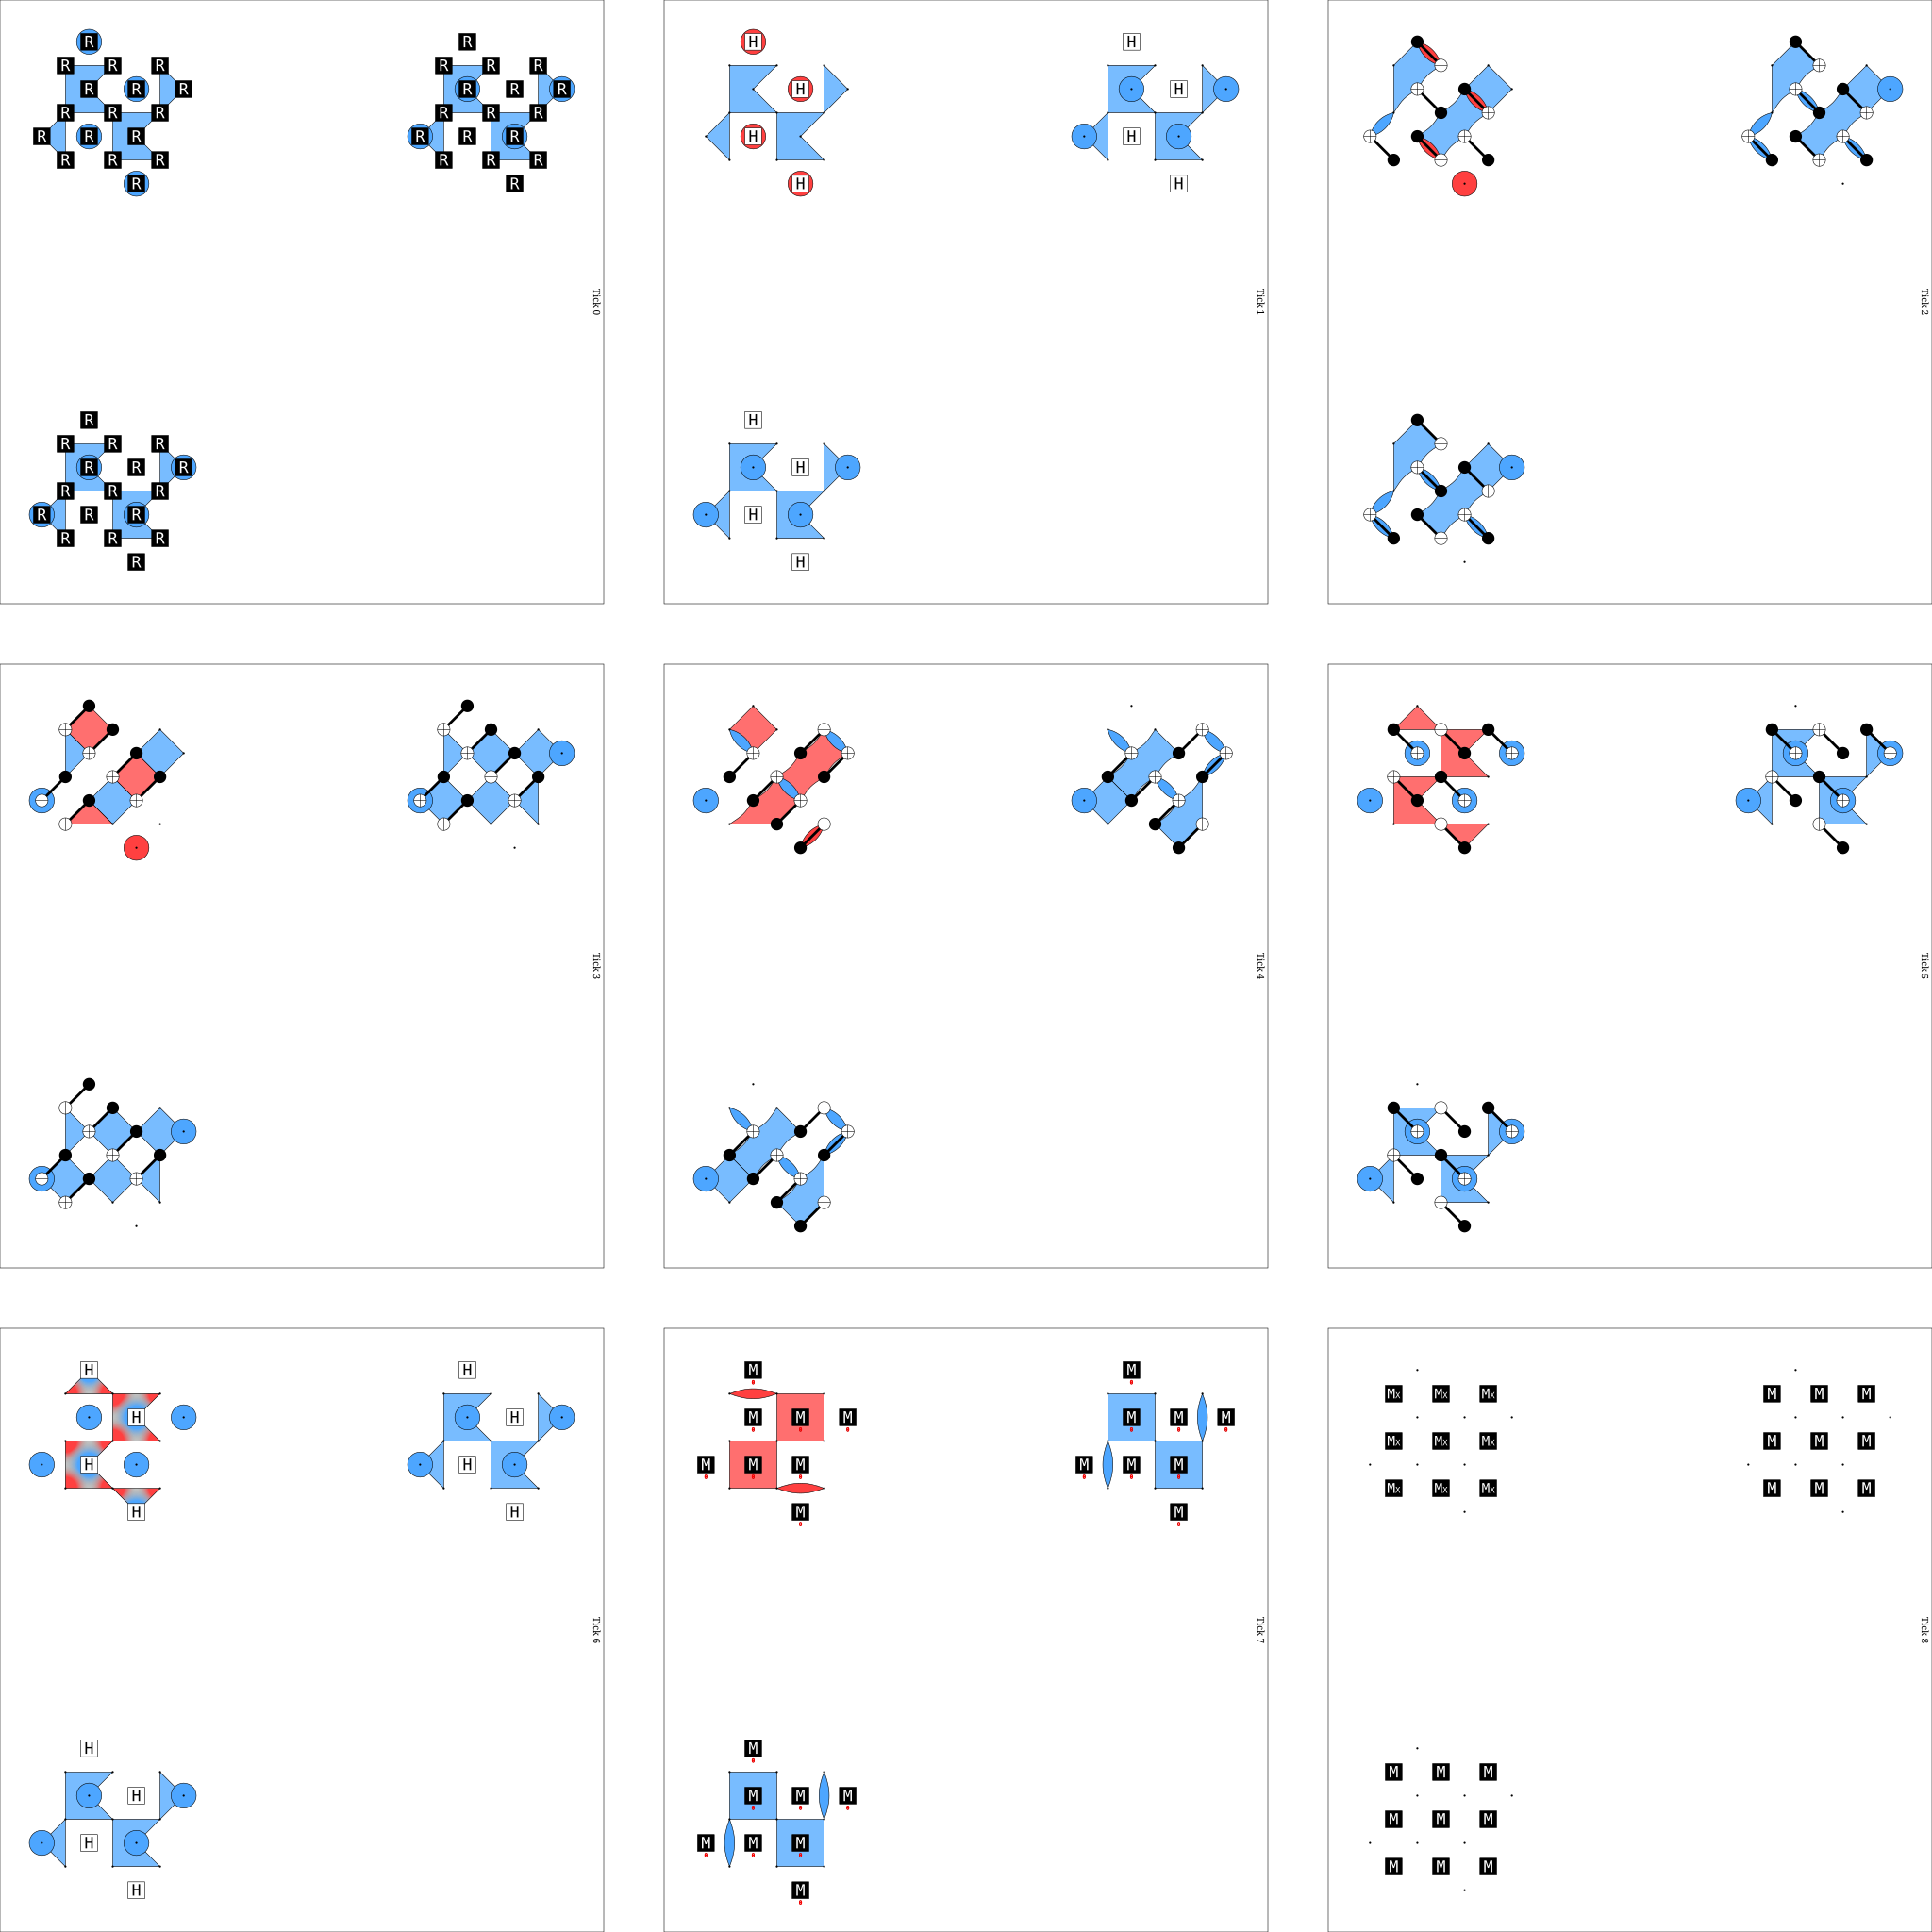

In [7]:
from IPython.display import SVG
display(SVG(str(circuit.diagram("detslice-with-ops-svg"))))

## 7. Simulation: fault distance and logical error rate

Uniform circuit-level depolarising noise: graphlike fault distance and logical error rate (PyMatching, 200 000 shots).

In [8]:
from noise_inject import inject_uniform_noise

for d in (3, 5):
    cp = compile_circuit(d)
    noisy = inject_uniform_noise(cp.circuit, 1e-3)
    dist = len(noisy.shortest_graphlike_error(ignore_ungraphlike_errors=False))
    print(f"d = {d}: {cp.circuit.num_qubits:4d} qubits, {cp.circuit.num_detectors:4d} detectors, "
          f"{cp.circuit.num_observables} observables, graphlike fault distance = {dist}")

d = 3:   51 qubits,   24 detectors, 4 observables, graphlike fault distance = 3


d = 5:  147 qubits,   72 detectors, 4 observables, graphlike fault distance = 5


In [9]:
import pymatching
import numpy as np

SHOTS = 200_000
for d in (3, 5):
    cp = compile_circuit(d)
    for p in (1e-3, 2e-3):
        noisy = inject_uniform_noise(cp.circuit, p)
        matcher = pymatching.Matching.from_detector_error_model(noisy.detector_error_model(decompose_errors=True))
        det, obs = noisy.compile_detector_sampler(seed=0).sample(SHOTS, separate_observables=True)
        errors = int(np.any(matcher.decode_batch(det) != obs, axis=1).sum())
        print(f"d = {d}, p = {p:.0e}: LER = {errors / SHOTS:.2e}  ({errors} / {SHOTS})")

d = 3, p = 1e-03: LER = 1.37e-03  (275 / 200000)
d = 3, p = 2e-03: LER = 5.29e-03  (1058 / 200000)


d = 5, p = 1e-03: LER = 1.20e-04  (24 / 200000)


d = 5, p = 2e-03: LER = 7.60e-04  (152 / 200000)
